<a href="https://colab.research.google.com/github/fvelascor/MCDIA/blob/master/Hands_On_Say_hello_to_the_%22Hello%2C_World%22_of_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How to say ***Hello World!*** in ML?

Dados los siguientes datos:

<div class="instructions"><div class="inner">
<div class="devsite-table-wrapper">
  <table class="vertical-rules">
    <tbody>
      <tr>
        <td colspan="1" rowspan="1"><p>X:</p></td>
        <td colspan="1" rowspan="1"><p>-1.0</p></td>
        <td colspan="1" rowspan="1"><p>0.0</p></td>
        <td colspan="1" rowspan="1"><p>1.0</p></td>
        <td colspan="1" rowspan="1"><p>2.0</p></td>
        <td colspan="1" rowspan="1"><p>3.0</p></td>
        <td colspan="1" rowspan="1"><p>4.0</p></td>
      </tr>
      <tr>
        <td colspan="1" rowspan="1"><p>Y:</p></td>
        <td colspan="1" rowspan="1"><p>-4.0</p></td>
        <td colspan="1" rowspan="1"><p>1.0</p></td>
        <td colspan="1" rowspan="1"><p>6.0</p></td>
        <td colspan="1" rowspan="1"><p>11.0</p></td>
        <td colspan="1" rowspan="1"><p>16.0</p></td>
        <td colspan="1" rowspan="1"><p>21.0</p></td>
      </tr>
    </tbody>
  </table>
</div>
</div></div>

Realice las operaciones dadas para una regresión lineal simple y visualizar los datos dados con **xs** y **ys**. Muestre el gráfico para analizar el comportamiento de los datos.

$Recordando$ $la$ $Regresión$ $Lineal$ $Simple:$

$
\overline{y} = β\overline{x} + α
$

Entrene una red neuronal para hacer coincidir **xs** con **ys**.

De modo que un predictor para un nuevo valor de X proporcione un valor flotante muy cercano a la respuesta deseada, es decir, **print(modelo.predict([X]))** debe dar un resultado satisfactorio.

La infraestructura de prueba, espera un modelo entrenado que acepte una forma de entrada de [1].

Realice un test de entrenamiento para verificar las epocas dadas y visualice el comportamiento de las perdidas según el algoritmo utilizado.  

Guarde el modelo anterior en un archivo con el nombre y tipo de dato **mymodel.h5**

**Solución:** https://colab.research.google.com/drive/15euxlQOV2v-8QwDs7GrR2b4QJZ1C5l27?usp=sharing

**Challenge:** https://colab.research.google.com/drive/1LEJVu0Wz-HN3jAQX-uKE9JRrd1181EHm?usp=sharing

In [14]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [15]:
# ==========================================
# DEFINICIÓN DEL DATASET
# ==========================================

# Variables independientes (X)
xs = np.array([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0], dtype=float)

# Variables dependientes (Y)
ys = np.array([-4.0, 1.0, 6.0, 11.0, 16.0, 21.0], dtype=float)

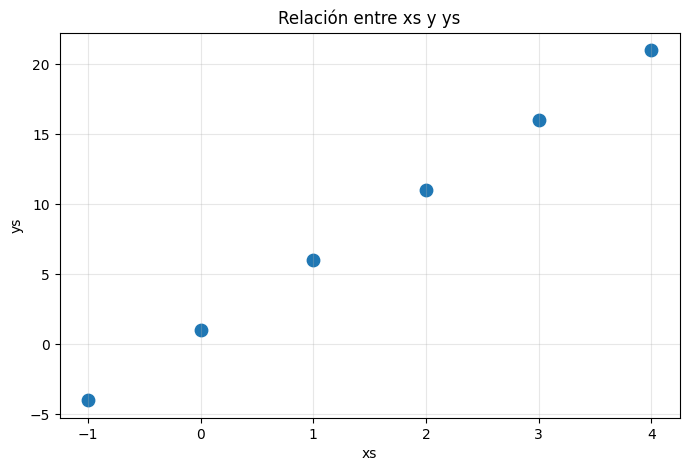

In [16]:
# ==========================================
# VISUALIZACIÓN DE LOS DATOS
# ==========================================

plt.figure(figsize=(8,5))

plt.scatter(xs, ys, s=80)

plt.title('Relación entre xs y ys')
plt.xlabel('xs')
plt.ylabel('ys')

plt.grid(alpha=0.3)

plt.show()

# ==========================================
# INTERPRETACIÓN
# ==========================================

# Los datos muestran una relación lineal positiva.
# Conforme aumenta X, Y también incrementa de forma constante.
#
# El comportamiento corresponde aproximadamente a:
#
# y = 5x + 1
#
# Objetivo:
# Entrenar una red neuronal para aprender automáticamente
# dicha relación matemática.

In [17]:
# ==========================================
# DEFINICIÓN DEL MODELO
# ==========================================

modelo = tf.keras.Sequential([

    tf.keras.layers.Dense(
        units=1,
        input_shape=[1]
    )

])

In [18]:
# ==========================================
# COMPILACIÓN DEL MODELO
# ==========================================

modelo.compile(

    optimizer='sgd',
    loss='mean_squared_error'

)

In [19]:
# ==========================================
# ENTRENAMIENTO DEL MODELO
# ==========================================

historial = modelo.fit(

    xs,
    ys,
    epochs=500,
    verbose=0

)

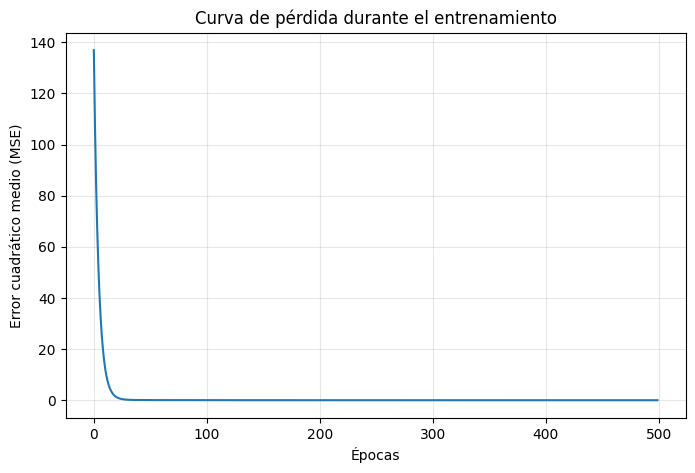

In [20]:
# ==========================================
# VISUALIZACIÓN DE LA FUNCIÓN DE PÉRDIDA
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(historial.history['loss'])

plt.title('Curva de pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Error cuadrático medio (MSE)')

plt.grid(alpha=0.3)

plt.show()

In [21]:
# ==========================================
# PREDICCIÓN DE VALORES
# ==========================================
print(modelo.predict(np.array([10.0])))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
[[50.99366]]


# ==========================================
# INTERPRETACIÓN
# ==========================================

# El modelo debería aproximarse a:
#
# y = 5(10) + 1
#
# Resultado esperado:
#
# ≈ 51
#
# Esto demuestra que la red neuronal logró aprender
# la relación lineal entre xs y ys.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


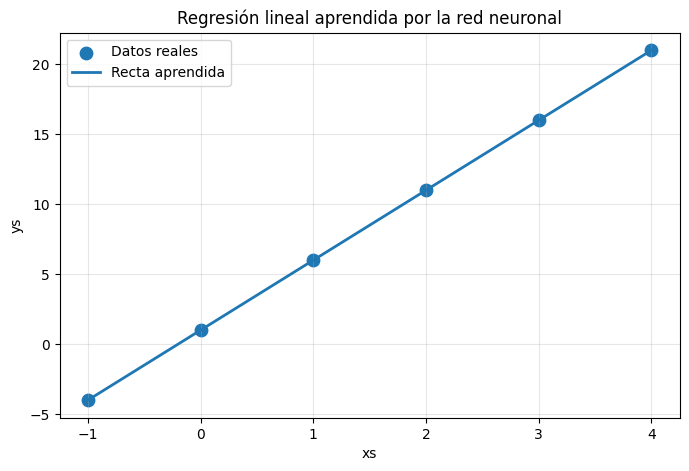

In [22]:
# ==========================================
# VISUALIZACIÓN DE LA RECTA APRENDIDA
# ==========================================

predicciones = modelo.predict(xs)

plt.figure(figsize=(8,5))

# Datos originales
plt.scatter(xs, ys, label='Datos reales', s=80)

# Predicción del modelo
plt.plot(xs, predicciones, linewidth=2, label='Recta aprendida')

plt.title('Regresión lineal aprendida por la red neuronal')

plt.xlabel('xs')
plt.ylabel('ys')

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [23]:
# ==========================================
# GUARDAR MODELO ENTRENADO
# ==========================================

modelo.save('mymodel.h5')

# ==========================================
# CONCLUSIÓN
# ==========================================

# Se construyó y entrenó una red neuronal simple
# utilizando TensorFlow y Keras.
#
# El modelo logró aprender exitosamente la relación:
#
# y = 5x + 1
#
# Además:
# - Se visualizaron los datos
# - Se observó la disminución del error
# - Se realizaron predicciones satisfactorias
# - Se guardó el modelo entrenado en formato .h5